## Model Training

In [1]:
#Basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot  as plt
import seaborn as sns

#Modelling
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor


### Reading the dataset using Pandas


In [2]:
df = pd.read_csv('data/stud.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Declaring  x and y 

In [3]:
X = df.drop(columns=['math_score'], axis = 1)
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [4]:
y = df['math_score']
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

##### Create column transformer with 3 types of transformers 

In [5]:
cat_features = X.select_dtypes(include="object").columns
num_features = X.select_dtypes(exclude="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transfomer = StandardScaler()
oh_transformer = OneHotEncoder() 

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transfomer, num_features),
    ]
)



In [6]:
X = preprocessor.fit_transform(X)

In [7]:
X

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]])

In [8]:
X.shape

(1000, 19)

### Sepearate train and test data

In [12]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size= 0.2, random_state= 42)
X_train.shape, X_test.shape

((800, 19), (200, 19))

### Create an evaluate function to give all metrics after model training.

In [17]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [19]:
models = {
    "LinearRegression" : LinearRegression(),
    "Lasso" : Lasso(),
    "Ridge" : Ridge(),
    "KNeighborsRegressor" : KNeighborsRegressor(),
    "DecisionTree" : DecisionTreeRegressor(),
    "Random Forest " : RandomForestRegressor(),
    "XGBregressor" : XGBRegressor(),
    "CatBoostRegressor" : CatBoostRegressor(verbose=False),
    "AdaBoostRegressor" : AdaBoostRegressor()
}


model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train,y_train) #train the model

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    #evaluate train test datasets
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model performance for training set")
    print('- Root Mean Squared Error : {:.4f}'.format(model_train_rmse))
    print('- Mean Absolute Error : {:.4f}'.format(model_train_mae))
    print('- R2 score : {:.4f}'.format(model_train_r2))

    print('-'* 50)

    print("Model performance for testing set")
    print('- Root Mean Squared Error : {:.4f}'.format(model_test_rmse))
    print('- Mean Absolute Error : {:.4f}'.format(model_test_mae))
    print('- R2 score : {:.4f}'.format(model_test_r2))

    r2_list.append(model_test_r2)

    print("=" * 32)
    print('\n')

LinearRegression
Model performance for training set
- Root Mean Squared Error : 5.3402
- Mean Absolute Error : 4.2723
- R2 score : 0.8735
--------------------------------------------------
Model performance for testing set
- Root Mean Squared Error : 5.4214
- Mean Absolute Error : 4.2253
- R2 score : 0.8792


Lasso
Model performance for training set
- Root Mean Squared Error : 6.5938
- Mean Absolute Error : 5.2063
- R2 score : 0.8071
--------------------------------------------------
Model performance for testing set
- Root Mean Squared Error : 6.5197
- Mean Absolute Error : 5.1579
- R2 score : 0.8253


Ridge
Model performance for training set
- Root Mean Squared Error : 5.3233
- Mean Absolute Error : 4.2650
- R2 score : 0.8743
--------------------------------------------------
Model performance for testing set
- Root Mean Squared Error : 5.3904
- Mean Absolute Error : 4.2111
- R2 score : 0.8806


KNeighborsRegressor
Model performance for training set
- Root Mean Squared Error : 5.7077

### Results

In [21]:
pd.DataFrame(list(zip(model_list,r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=['R2_Score'], ascending=False)

,Model Name,R2_Score
2,Ridge,0.880593
0,LinearRegression,0.879216
8,AdaBoostRegressor,0.853213
5,Random Forest,0.852907
7,CatBoostRegressor,0.851632
6,XGBregressor,0.827797
1,Lasso,0.825320
3,KNeighborsRegressor,0.783813
4,DecisionTree,0.743053


### Linear Regression

In [23]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train,y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print("Accuracy of the model is %.2f" %score)

Accuracy of the model is 87.92


### plot y_pred and y_test

Text(0, 0.5, 'predicted')

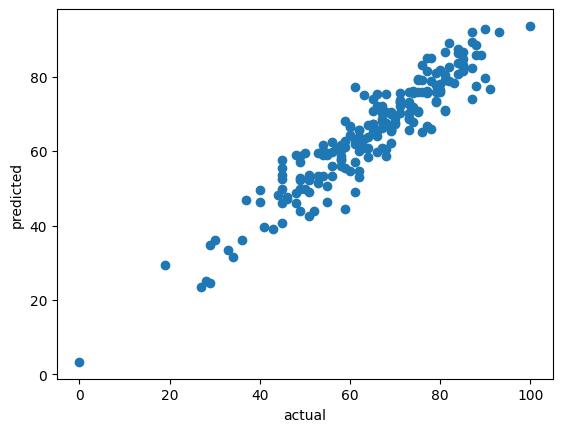

In [24]:
plt.scatter(y_test, y_pred)
plt.xlabel('actual')
plt.ylabel('predicted')

<Axes: xlabel='math_score'>

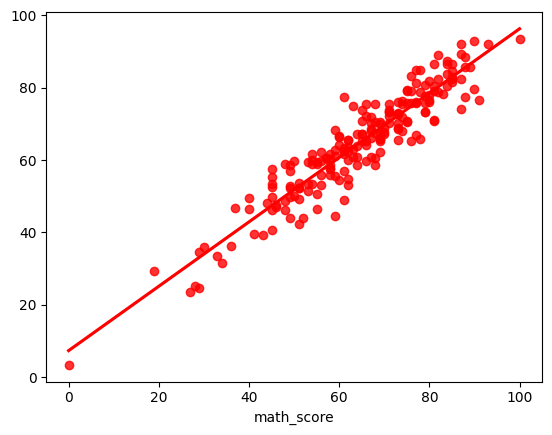

In [25]:
sns.regplot(x=y_test, y=y_pred, ci=None, color= 'red')

### Difference between real and predicted values

In [26]:
pred_df = pd.DataFrame({"Actual values" : y_test, "predicted_value": y_pred, "difference": y_test-y_pred})
pred_df

,Actual values,predicted_value,difference
521,91,76.6250,14.3750
737,53,59.3750,-6.3750
740,80,76.5000,3.5000
660,74,76.2500,-2.2500
411,84,87.4375,-3.4375
...,...,...,...
408,52,43.8750,8.1250
332,62,62.6250,-0.6250
208,74,67.9375,6.0625
613,65,67.2500,-2.2500
